# Reducción de Dimensionalidad (PCA)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/02_eda/05_reduccion_dimensionalidad.ipynb)



## Objetivos
- Comprender el problema conocido como maldición de la dimensionalidad y cómo afecta a muchos algoritmos de Machine Learning.
- Entender la intuición matemática detrás del Análisis de Componentes Principales (PCA).
- Interpretar la varianza explicada y utilizar el *Scree Plot* para decidir cuántos componentes conservar.
- Aplicar PCA para reducir dimensionalidad manteniendo la mayor parte de la información del dataset.
- Utilizar PCA como herramienta para visualizar datasets de alta dimensión en 2D o 3D.
- Reconocer las limitaciones de PCA, especialmente en términos de interpretabilidad y relaciones no lineales.

## Prerrequisitos
- [Escalado y Transformación de Datos, especialmente el uso de `StandardScaler`.](04_escalado_y_transformacion.ipynb)
- Conceptos básicos de estadística descriptiva: media, mediana, desviación estándar.


---
## Configuración del Entorno

In [ ]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

# Detectar Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Ejecución en Google Colab. Clonando repositorio...")
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

# Importar utilidades globales
from utils.plots import setup_plot_style
setup_plot_style()

Ejecución en Google Colab. Clonando repositorio...


## 1. La Maldición de la Dimensionalidad



A medida que agregamos más características (columnas o *features*) a nuestro dataset, el espacio matemático donde viven los datos crece exponencialmente.
Imagina que buscas una moneda (un dato) en una línea de 10 metros (1 dimensión). Es fácil. Si la buscas en un cuadrado de 10x10 metros (2 dimensiones), tardarás más. Si la buscas en un cubo gigante de 10x10x10 metros... se vuelve casi imposible.

A esto se le llama **Maldición de la Dimensionalidad**. Muchos algoritmos (especialmente KNN) fallan estrepitosamente si hay cientos de columnas, porque en dimensiones muy altas, *todos los puntos están igual de lejos entre sí*.

¿La solución? Comprimir la información. Quitar columnas redundantes y quedarnos solo con lo que aporta valor.



## 2. Intuición de PCA (Análisis de Componentes Principales)



Supongamos que se toma una foto 2D de un objeto en 3D. Según desde qué ángulo se tome la foto, se capturan más o menos detalles del objeto.
**PCA hace exactamente eso.** Busca el "ángulo" matemático desde el cual se ve la mayor cantidad de separación (Varianza) en los datos, y proyecta los datos sobre ese ángulo. Ese ángulo pasa a ser el **Componente Principal 1 (PC1)**. Luego busca el siguiente mejor ángulo ortogonal para el PC2, y así sucesivamente.



### Veamos la compresión de un dataset real



Utilizamos un dataset clásico de cáncer de mama, que tiene 30 características clínicas (demasiadas para graficar fácilmente).



Dimensiones originales: (569, 30)


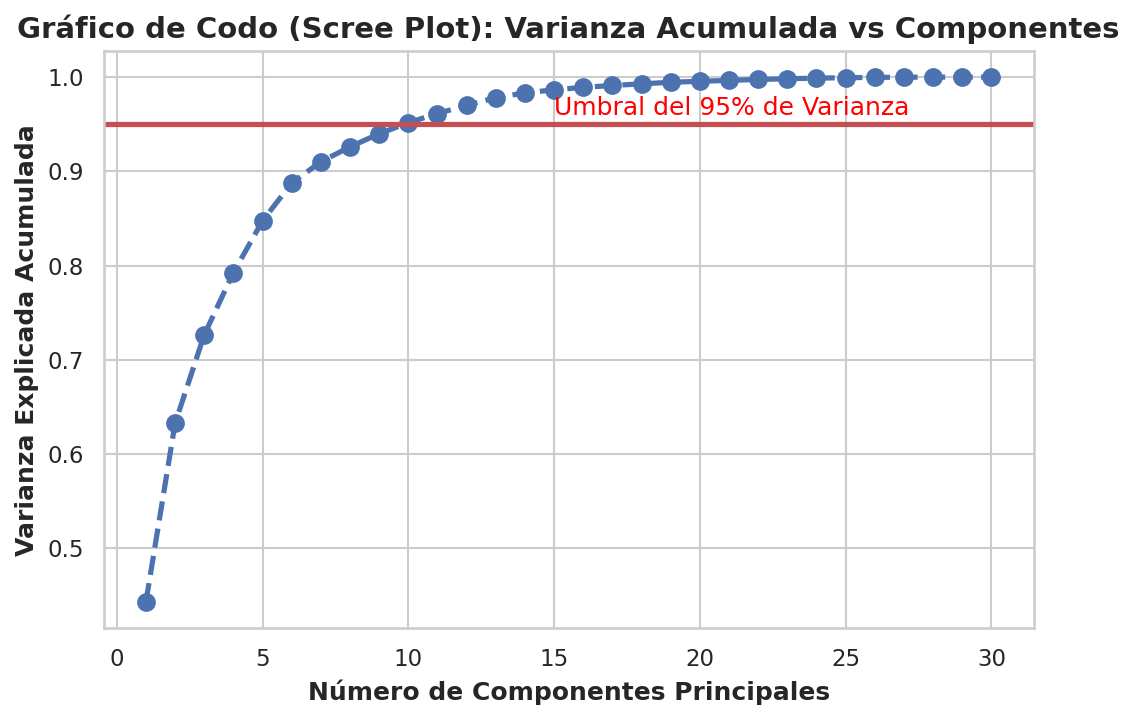

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Cargar dataset de 30 dimensiones
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(f"Dimensiones originales: {X.shape}")

# ⚠️ PCA REQUIERE ESTANDARIZACIÓN PREVIA ⚠️
# PCA busca ejes de máxima varianza. Si no escalamos, una columna medida en "miles"
# dominará completamente a una columna medida en "decimales" solo por su magnitud.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Inicializamos PCA sin límite para ver todas las componentes
pca_completo = PCA()
pca_completo.fit(X_scaled)

# Varianza Explicada Acumulada
varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(15, 0.96, 'Umbral del 95% de Varianza', color='red')
plt.title('Gráfico de Codo (Scree Plot): Varianza Acumulada vs Componentes')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.show()


### ¿Cómo interpretar el "*Scree Plot*"?



El gráfico nos muestra que **no necesitamos las 30 columnas**.
Con apenas las primeras **10 Componentes Principales**, logramos retener el **95%** de toda la varianza (información) del dataset original. Pudimos "comprimir" el problema un 66% sin perder casi nada de fidelidad, eliminando ruido y correlaciones redundantes.



## 3. Visualización en 2D: El "Súper Poder" de PCA



Una de las grandes ventajas de PCA es que nos permite ver datasets de altísima dimensionalidad en una pantalla 2D.
Si proyectamos las 30 columnas a solo 2 Componentes (PC1 y PC2), ¿podremos distinguir el cáncer maligno del benigno?



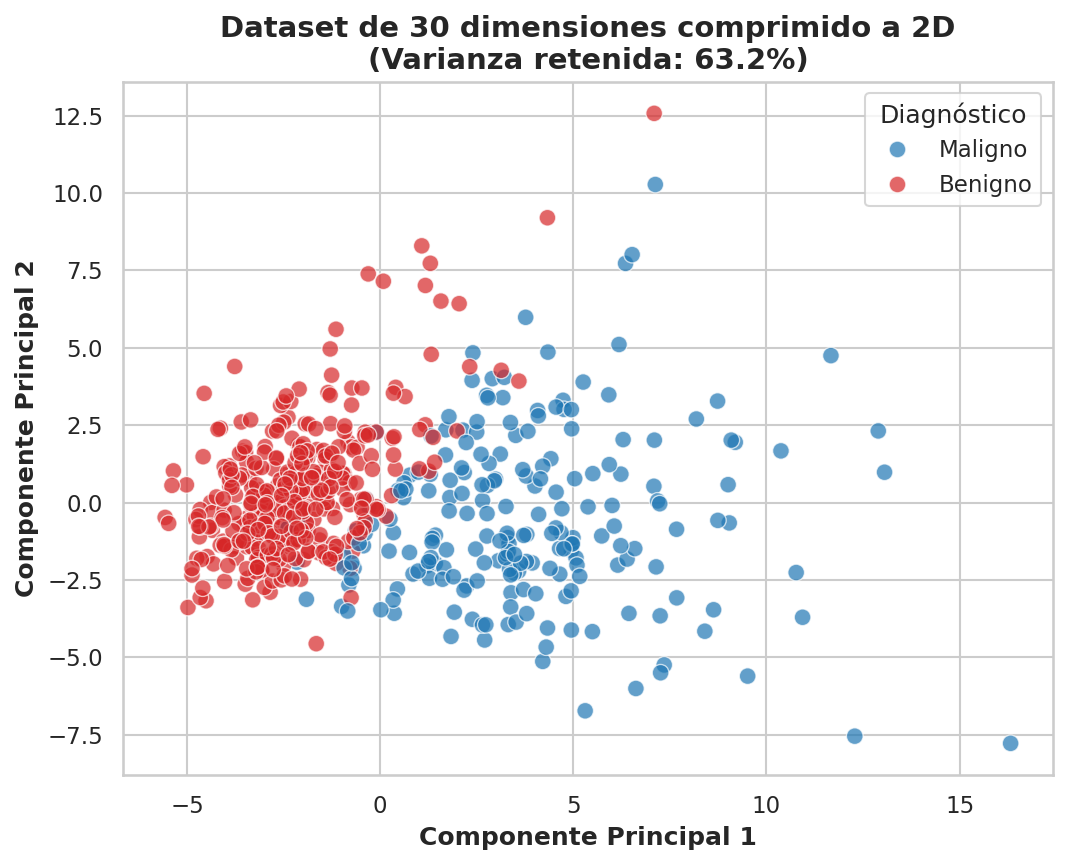

In [3]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
df_pca['Diagnóstico'] = ['Benigno' if t == 1 else 'Maligno' for t in y]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Diagnóstico',
    palette=['#1f77b4', '#d62728'],
    data=df_pca,
    alpha=0.7
)
plt.title(f"Dataset de 30 dimensiones comprimido a 2D\n(Varianza retenida: {sum(pca_2d.explained_variance_ratio_):.1%})")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()



A pesar de haber destruido el 37% de la información (solo retuvimos el `63.2%` en estas 2 componentes), ¡las dos clases son casi perfectamente separables por una línea recta en este nuevo espacio!
Un modelo lineal entrenado **solo con estas 2 columnas nuevas** funcionaría de maravilla y sería rapidísimo.



## 4. Limitaciones y Consideraciones



- **Pérdida de Explicabilidad:** Los componentes principales (`PC1`, `PC2`) son combinaciones lineales matemáticas de las variables originales (ej. `0.3*Radio + 0.2*Textura - 0.1*Area...`). Ya no se podría decirle al médico: "El modelo predice cáncer porque el *radio* es alto". Si se necesita explicabilidad total de las variables originales, no usar PCA para la inferencia final.
- **Requiere Escala:** Si nos "**olvidamos**" de aplicar un `StandardScaler` o `RobustScaler` antes del PCA, el algoritmo fallará catastróficamente, sesgando los componentes hacia las variables con números más grandes independientemente de su verdadera varianza.
- **Relaciones Lineales:** PCA asume que las relaciones entre variables son lineales. Si se tienen datos *enroscados* como un espiral suizo en 3D, PCA no podrá desenrollarlos (para eso existen técnicas como t-SNE o UMAP, que vemos más adelante).



## 5. Entorno de Ejecución


In [4]:
from utils.environment import environment_table
environment_table(include_all=False)


Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
